# Car Insurance Fraud EDA

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Data loading

In [2]:
df = pd.read_csv('../data/car_insurance_fraud_dataset.csv')

In [3]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 30000 rows, 24 columns


In [4]:
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,NaN,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,NaN,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [5]:
print(df.dtypes)

policy_id                       object
policy_state                    object
policy_deductible                int64
policy_annual_premium          float64
insured_age                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
bodily_injuries                  int64
witnesses                        int64
police_report_available         object
claim_amount                   float64
total_claim_amount             float64
fraud_reported                  object
dtype: object


Columns Overview:

policy_id: Unique policy identifier

policy_state: State where the policy was issued

policy_deductible: Deductible amount in USD

policy_annual_premium: Annual premium paid

insured_age: Age of the insured

insured_sex: Gender of the insured

insured_education_level: Education level

insured_occupation: Occupation type

insured_hobbies: Hobby type

incident_date: Date of the incident

incident_type: Type of incident (collision, theft, etc.)

collision_type: Collision direction (front/rear/side)

incident_severity: Level of damage

authorities_contacted: Who was contacted (Police/Fire/etc.)

incident_state: State where incident occurred

incident_city: City name

incident_hour_of_the_day: Time of the incident

number_of_vehicles_involved: Vehicles involved

bodily_injuries: Injuries reported

witnesses: Number of witnesses

police_report_available: Whether a police report exists

claim_amount: Claimed amount (USD)

total_claim_amount: Estimated total damage (USD)

fraud_reported: Target label (Y for fraud, N for legitimate)

## Data cleaning

In [6]:
print('Any duplicates?', df.duplicated().any())

Any duplicates? False


In [7]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
policy_id                         0
policy_state                      0
policy_deductible                 0
policy_annual_premium             0
insured_age                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted          7564
incident_state                    0
incident_city                     0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
bodily_injuries                   0
witnesses                         0
police_report_available           0
claim_amount                      0
total_claim_amount                0
fraud_reported                    0
dtype: int64


In [8]:
df['authorities_contacted'].map(type).unique()

array([<class 'float'>, <class 'str'>], dtype=object)

In [9]:
df['authorities_contacted'].unique()

array([nan, 'Police', 'Fire', 'Ambulance'], dtype=object)

In [10]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('No contact')

In [11]:
df['authorities_contacted'].unique()

array(['No contact', 'Police', 'Fire', 'Ambulance'], dtype=object)

In [12]:
df['authorities_contacted'].map(type).unique()

array([<class 'str'>], dtype=object)

In [13]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
policy_id                      0
policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0
dtype: int64


In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f'{col}: {len(outliers)} outliers')

policy_deductible: 0 outliers
policy_annual_premium: 0 outliers
insured_age: 0 outliers
incident_hour_of_the_day: 0 outliers
number_of_vehicles_involved: 0 outliers
bodily_injuries: 0 outliers
witnesses: 0 outliers
claim_amount: 0 outliers
total_claim_amount: 0 outliers


In [15]:
df['incident_date'] = pd.to_datetime(df['incident_date'])

## Exploratory Data Analysis

In [16]:
df.dtypes

policy_id                              object
policy_state                           object
policy_deductible                       int64
policy_annual_premium                 float64
insured_age                             int64
insured_sex                            object
insured_education_level                object
insured_occupation                     object
insured_hobbies                        object
incident_date                  datetime64[ns]
incident_type                          object
collision_type                         object
incident_severity                      object
authorities_contacted                  object
incident_state                         object
incident_city                          object
incident_hour_of_the_day                int64
number_of_vehicles_involved             int64
bodily_injuries                         int64
witnesses                               int64
police_report_available                object
claim_amount                      

In [17]:
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,Front,Total Loss,No contact,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,Rear,Total Loss,No contact,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,Unknown,Total Loss,Police,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,Rear,Total Loss,Police,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,Side,Minor Damage,Fire,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


Non-numerical data

In [18]:
df.describe(exclude='number').T

,count,unique,top,freq,mean,min,25%,50%,75%,max
policy_id,30000,30000,POL100000,1,NaT,NaT,NaT,NaT,NaT,NaT
policy_state,30000,10,GA,3133,NaT,NaT,NaT,NaT,NaT,NaT
insured_sex,30000,3,OTHER,10088,NaT,NaT,NaT,NaT,NaT,NaT
insured_education_level,30000,4,High School,7554,NaT,NaT,NaT,NaT,NaT,NaT
insured_occupation,30000,8,Teacher,3799,NaT,NaT,NaT,NaT,NaT,NaT
insured_hobbies,30000,7,paintball,4345,NaT,NaT,NaT,NaT,NaT,NaT
incident_date,30000,NaN,NaN,NaN,2024-11-08 18:05:57.120,2023-11-09,2024-05-10,2024-11-10,2025-05-09,2025-11-08
incident_type,30000,4,Vehicle Theft,7581,NaT,NaT,NaT,NaT,NaT,NaT
collision_type,30000,4,Rear,7566,NaT,NaT,NaT,NaT,NaT,NaT
incident_severity,30000,3,Total Loss,10108,NaT,NaT,NaT,NaT,NaT,NaT


Numerical columns

In [19]:
df.describe(exclude='object').T

,count,mean,min,25%,50%,75%,max,std
policy_deductible,30000.0,562.783333,200.0,300.0,600.0,800.0,1000.0,250.413012
policy_annual_premium,30000.0,1051.255214,600.02,826.32,1051.155,1277.9025,1499.98,260.357163
insured_age,30000.0,46.500133,18.0,32.0,46.0,61.0,75.0,16.707778
incident_date,30000,2024-11-08 18:05:57.120000,2023-11-09 00:00:00,2024-05-10 00:00:00,2024-11-10 00:00:00,2025-05-09 00:00:00,2025-11-08 00:00:00,NaN
incident_hour_of_the_day,30000.0,11.505,0.0,6.0,12.0,17.0,23.0,6.896155
number_of_vehicles_involved,30000.0,2.508933,1.0,2.0,3.0,4.0,4.0,1.116555
bodily_injuries,30000.0,1.9976,0.0,1.0,2.0,3.0,4.0,1.411829
witnesses,30000.0,2.504667,0.0,1.0,2.0,4.0,5.0,1.707691
claim_amount,30000.0,10823.078981,266.74,5350.9475,10204.17,15381.8675,29719.87,6629.690781
total_claim_amount,30000.0,12757.7366,502.18,6685.5075,12740.43,18809.91,24999.72,7028.920069


### Which features correlate with higher rates of fraud?

#### Demographic & Profile Analysis

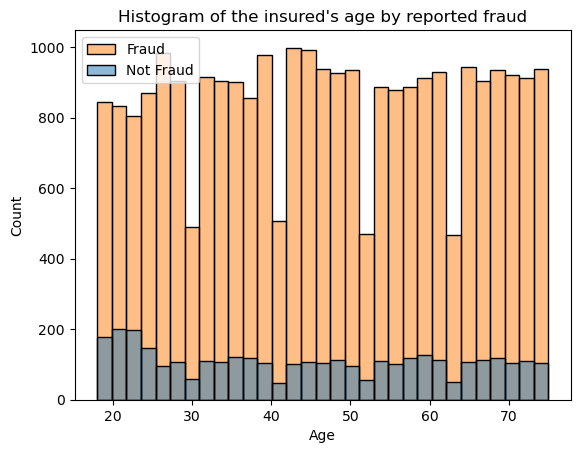

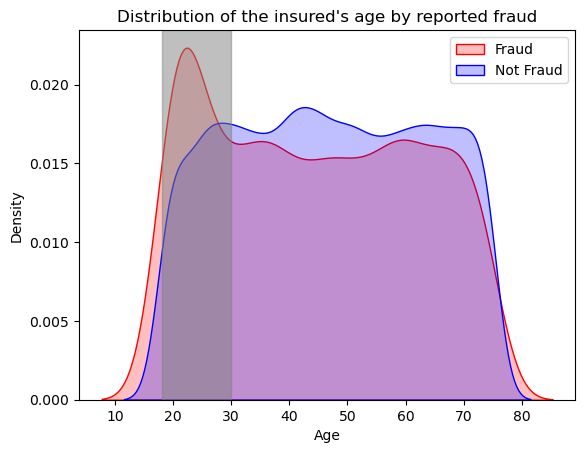

In [20]:
plt.subplot()
sns.histplot(data=df, x='insured_age', hue='fraud_reported')
plt.xlabel('Age')
plt.title('Histogram of the insured\'s age by reported fraud')
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

plt.subplot()
sns.kdeplot(df['insured_age'][df['fraud_reported'] == 'Y'], color='red', fill=True)
sns.kdeplot(df['insured_age'][df['fraud_reported'] == 'N'], color='blue', fill=True)
plt.axvspan(18, 30, color='gray', alpha=0.5)
plt.xlabel('Age')
plt.title('Distribution of the insured\'s age by reported fraud')
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

The distribution graph is slightly positively skewed, inferring that fraud reported cases are on drivers aged between 18 and 30

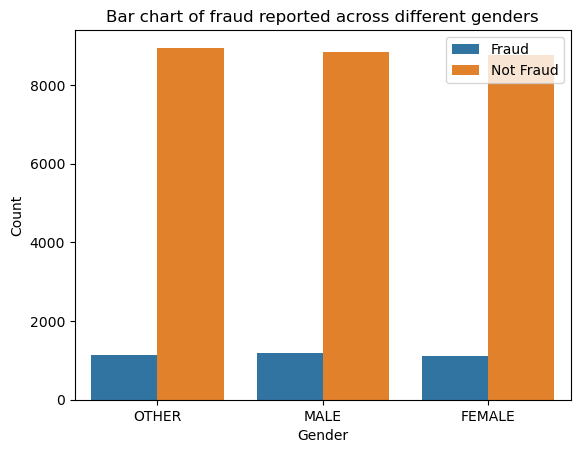

In [21]:
sns.countplot(data=df, x='insured_sex', hue='fraud_reported')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across different genders')
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

There is no significant amount to indicate that any gender makes more fraudulent claims

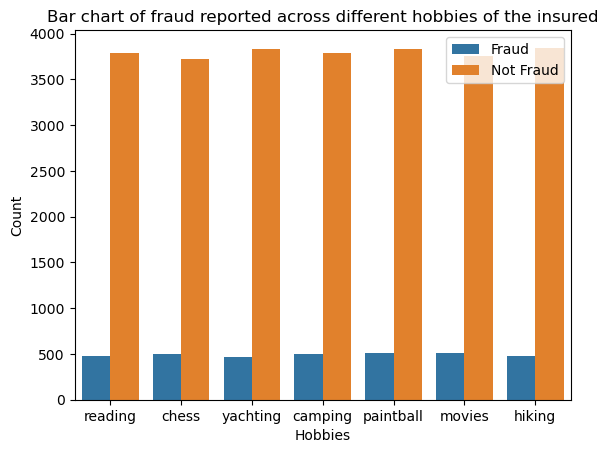

In [22]:
sns.countplot(data=df, x='insured_hobbies', hue='fraud_reported')
plt.xlabel('Hobbies')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across different hobbies of the insured')
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

There is no significant amount to indicate that hobbies of the insured causes more fraudulent claims

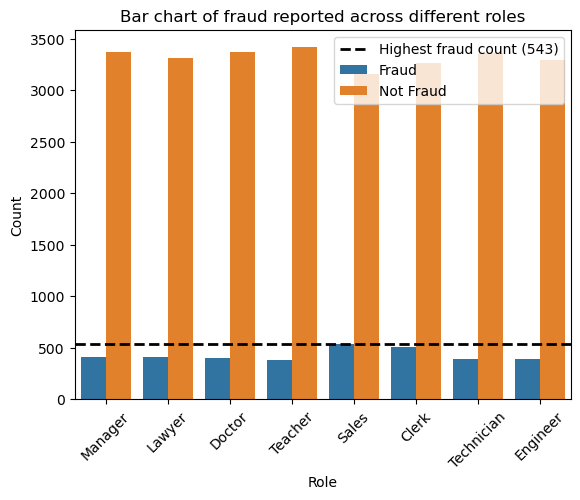

In [23]:
highest_fraud_count = (
    df[df['fraud_reported'] == 'Y']['insured_occupation']
    .value_counts()
    .max()
)

ax = sns.countplot(data=df, x='insured_occupation', hue='fraud_reported')
plt.axhline(
    y=highest_fraud_count,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Highest fraud count ({highest_fraud_count})'
)

plt.xlabel('Role')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across different roles')
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles, [f'Highest fraud count ({highest_fraud_count})', 'Fraud', 'Not Fraud'])
plt.xticks(rotation=45)
plt.show()

The highest fraud count is 543 from the drivers that are in sales, followed by clerks.

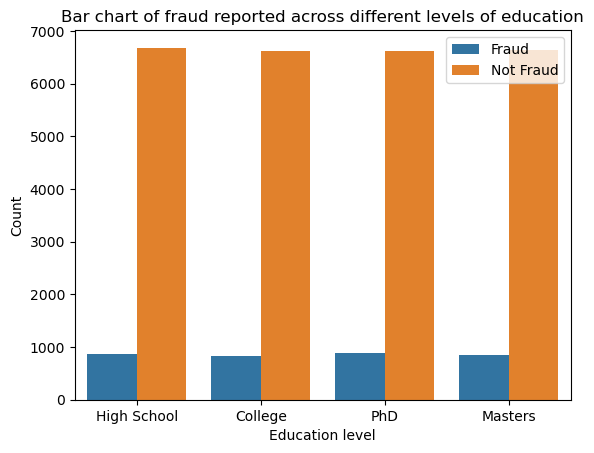

In [24]:
sns.countplot(data=df, x='insured_education_level', hue='fraud_reported')
plt.xlabel('Education level')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across different levels of education')
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

There is no significant amount to indicate that education level affects fraud rate

#### Policy & Financial Analysis

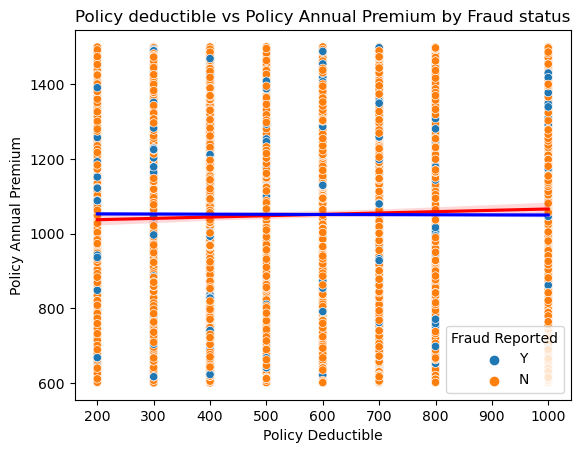

In [25]:
sns.scatterplot(data=df, x='policy_deductible', y='policy_annual_premium', hue='fraud_reported')

sns.regplot(
    data=df[df['fraud_reported'] == 'Y'],
    x='policy_deductible',
    y='policy_annual_premium',
    scatter=False,
    color='red'
)

sns.regplot(
    data=df[df['fraud_reported'] == 'N'],
    x='policy_deductible',
    y='policy_annual_premium',
    scatter=False,
    color='blue'
)

plt.xlabel('Policy Deductible')
plt.ylabel('Policy Annual Premium')
plt.title('Policy deductible vs Policy Annual Premium by Fraud status')
plt.legend(title='Fraud Reported')
plt.show()

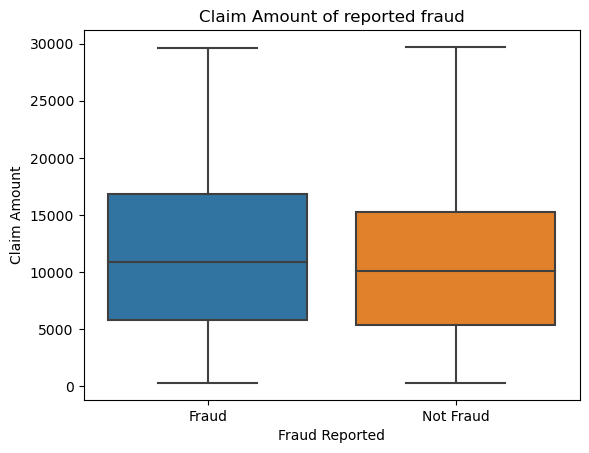

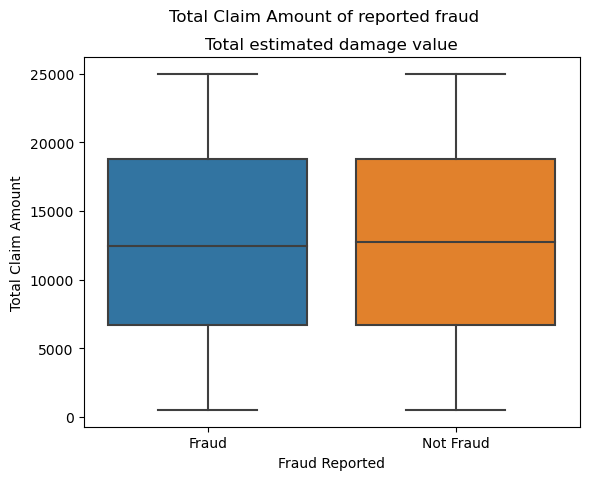

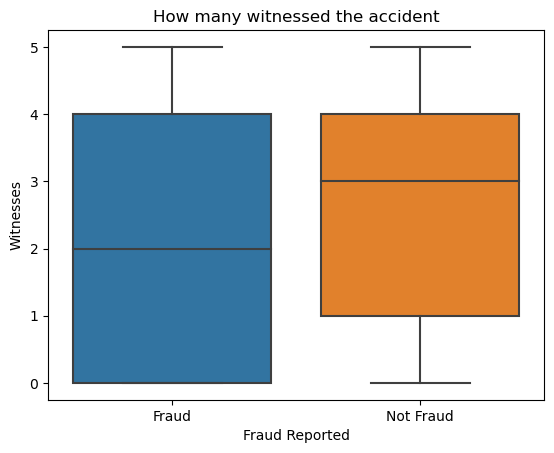

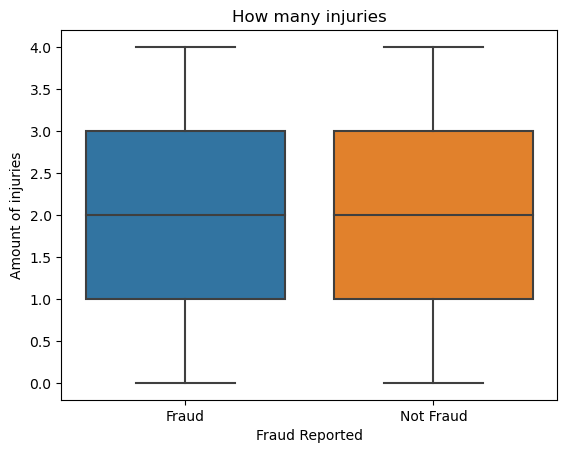

In [26]:
plt.subplot()
sns.boxplot(data=df, x='fraud_reported', y='claim_amount')
plt.xlabel('Fraud Reported')
plt.ylabel('Claim Amount')
plt.title('Claim Amount of reported fraud')
plt.xticks([0, 1], ['Fraud', 'Not Fraud'])
plt.show()

plt.subplot()
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount')
plt.xlabel('Fraud Reported')
plt.ylabel('Total Claim Amount')
plt.suptitle('Total Claim Amount of reported fraud')
plt.title('Total estimated damage value')
plt.xticks([0, 1], ['Fraud', 'Not Fraud'])
plt.show()

plt.subplot()
sns.boxplot(data=df, x='fraud_reported', y='witnesses')
plt.xlabel('Fraud Reported')
plt.ylabel('Witnesses')
plt.title('How many witnessed the accident')
plt.xticks([0, 1], ['Fraud', 'Not Fraud'])
plt.show()

plt.subplot()
sns.boxplot(data=df, x='fraud_reported', y='bodily_injuries')
plt.xlabel('Fraud Reported')
plt.ylabel('Amount of injuries')
plt.title('How many injuries')
plt.xticks([0, 1], ['Fraud', 'Not Fraud'])
plt.show()

The boxplots show that those that are fraudulently claiming money are getting more than those that are not fraudulent.
Total claim amount, which is the estimated total damage, and the amount of bodily injuries are almost the same among the fraudulent and non-fraudulent, and this may be because those that are fraudulent have to avoid detection by acting similarly to legitimate claims.
However, when it comes to witnesses, fraudulent cases may have zero witnesses, which is likely because they do not want others to give a bad testimony against the bad driver

#### Incident & Collision Analysis

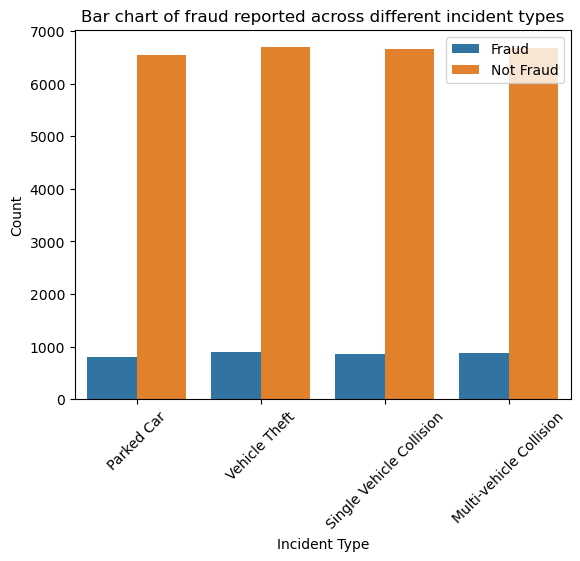

In [27]:
sns.countplot(data=df, x='incident_type', hue='fraud_reported')
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across different incident types')
plt.xticks(rotation=45)
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

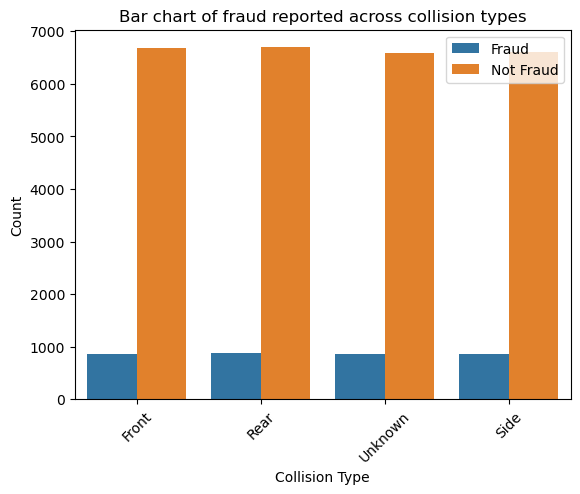

In [28]:
sns.countplot(data=df, x='collision_type', hue='fraud_reported')
plt.xlabel('Collision Type')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across collision types')
plt.xticks(rotation=45)
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

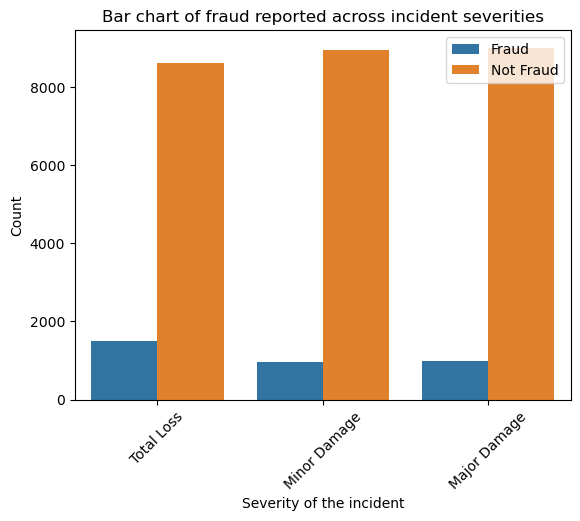

In [29]:
sns.countplot(data=df, x='incident_severity', hue='fraud_reported')
plt.xlabel('Severity of the incident')
plt.ylabel('Count')
plt.title('Bar chart of fraud reported across incident severities')
plt.xticks(rotation=45)
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

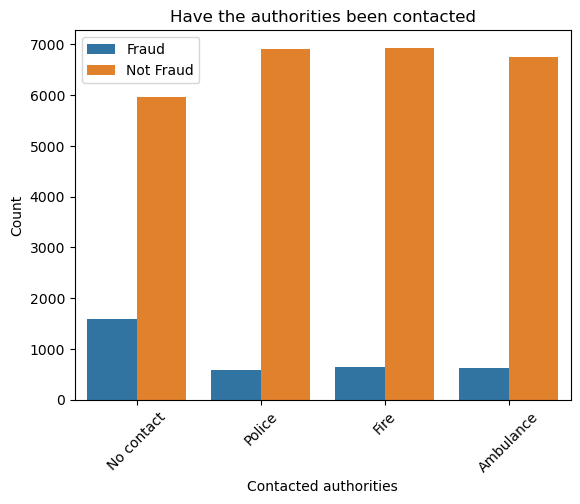

In [30]:
sns.countplot(data=df, x='authorities_contacted', hue='fraud_reported')
plt.xlabel('Contacted authorities')
plt.ylabel('Count')
plt.title('Have the authorities been contacted')
plt.xticks(rotation=45)
plt.legend(['Fraud', 'Not Fraud'])
plt.show()

The bar charts show that for fraudulent claimants it would be best not to contact the authorities, for most fraud cases, to avoid detection and fault. Also, for fraudulent cases, most cases have "Total Loss" scenarios and this is to maximize total payout.
It is not so important the collision type and incident type for fraudsters

#### Temporal Analysis

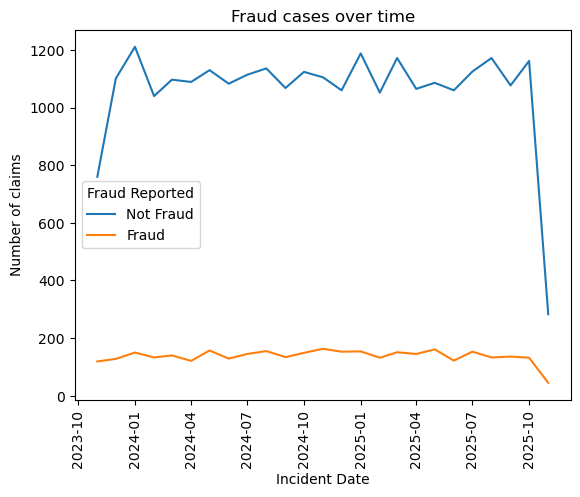

In [31]:
monthly_fraud = (
    df.groupby([df['incident_date'].dt.to_period('M'), 'fraud_reported'])
      .size()
      .reset_index(name='count')
)

monthly_fraud['incident_date'] = monthly_fraud['incident_date'].dt.to_timestamp()

ax = sns.lineplot(data=monthly_fraud, x='incident_date', y='count', hue='fraud_reported')

handles, labels = ax.get_legend_handles_labels()

new_labels = ['Fraud' if l == 'Y' else 'Not Fraud' for l in labels]
ax.legend(handles, new_labels, title='Fraud Reported')

plt.xlabel('Incident Date')
plt.ylabel('Number of claims')
plt.title('Fraud cases over time')
plt.xticks(rotation=90)
plt.show()

The fraud cases look linear across months, indicating that there is no specific month of the year in which more fraudulent cases happen or are found

#### Correlation heatmap

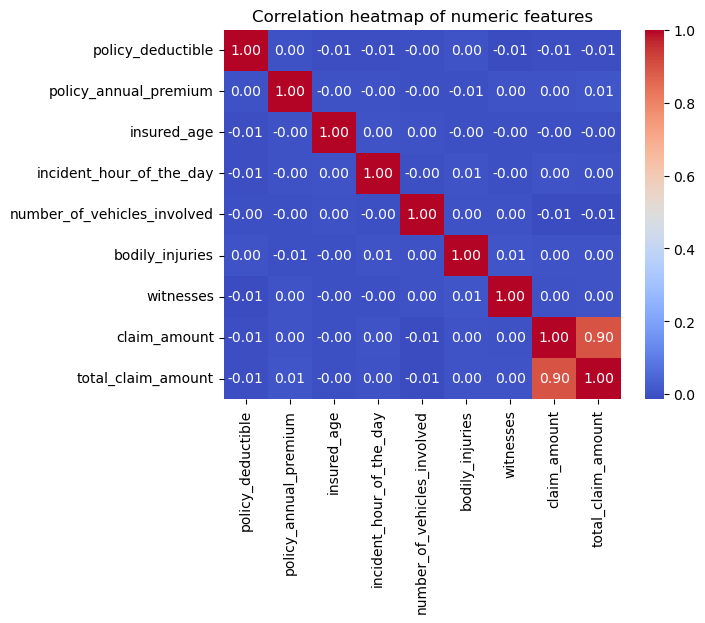

In [32]:
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap of numeric features')
plt.show()

There is multicollinearity between claim amount and total claim, and so for the model training, one of these features will have to be dropped.
As for other features, there is no linear relationship. This means that linear models will not yield useful results, but tree models and XGBoost may perform better